# LH Nautical — Etapa 3: Analise de Vendas & Rentabilidade

**Descoberta central:** ao integrar o historico real de cambio USD/BRL via API do Banco Central do Brasil,
a analise revela que a operacao acumula **R$ 139M de prejuizo** em 2023-2024 — margem geral de **-5,3%**
e 127 dos 150 produtos no vermelho.

| Secao | Conteudo |
|---|---|
| 1 | Taxa de cambio real — API PTAX/BCB -> silver_cambio (Delta Lake) |
| 2 | Enriquecimento — `custo_brl`, `lucro`, `margem_pct` por transacao (Spark SQL sobre Delta Lake) |
| 3 | Resultado operacional — receita x custo x lucro por ano |
| 4 | Evolucao mensal — como o cambio corroeu as margens |
| 5 | Rentabilidade por produto — scatter + ranking |
| 5.1 | Pareto — quais produtos concentram 80% do prejuizo |
| 6 | Break-even cambial — a que taxa cada produto vira prejuizo |
| 7 | Rentabilidade por categoria |
| 8 | Faturamento historico (contexto de volume) |
| 9 | YoY 2023 vs 2024 — a depreciacao cambial corroeu a margem? |
| 10 | Simulador de cenario cambial — sensibilidade ao USD/BRL |
| 11 | Reajuste de preco necessario por produto |
| 12 | Resumo executivo |

**Premissas:**
- Custo vigente: `usd_price` mais recente com `start_date <= sale_date` (subquery correlacionada)
- Cambio: PTAX de fechamento do dia da venda; fins de semana/feriados -> forward-fill
- `total` nas vendas = receita bruta em BRL

## 0. Setup

### Como Executar Este Notebook
1. Execute as células em ordem, do topo ao fim.
2. Este notebook lê a Camada Ouro (`gold_fct_vendas`) e a tabela `silver_cambio` do Delta Lake.
3. Câmbio PTAX/BCB já está embutido na Camada Ouro — sem dependências externas.
4. Ao final, rode a célula de checks para validar consistência dos principais resultados.

In [0]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Compatibilidade: Databricks Runtime (UI) vs databricks-connect (VS Code) ─
try:
    spark  # já definido no Databricks runtime
    dbutils.widgets.text("catalog", "workspace",   "Catalog")
    dbutils.widgets.text("schema",  "lh_nautical", "Schema")
    CATALOG = dbutils.widgets.get("catalog")
    SCHEMA  = dbutils.widgets.get("schema")
except NameError:
    from databricks.connect import DatabricksSession
    spark   = DatabricksSession.builder.serverless().getOrCreate()
    CATALOG = "workspace"
    SCHEMA  = "lh_nautical"

vendas_gold = spark.table(f"{CATALOG}.{SCHEMA}.gold_fct_vendas").toPandas()
vendas_gold["sale_date"] = pd.to_datetime(vendas_gold["sale_date"])

produtos = spark.table(f"{CATALOG}.{SCHEMA}.silver_produtos").toPandas()
cambio   = spark.table(f"{CATALOG}.{SCHEMA}.silver_cambio").toPandas()
cambio["data"] = pd.to_datetime(cambio["data"])

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"]    = "DejaVu Sans"

print(f"vendas_gold: {len(vendas_gold):,} linhas | produtos: {len(produtos)} | cambio: {len(cambio)}")
print("Setup concluido.")

vendas_gold: 9,895 linhas | produtos: 150 | cambio: 731
Setup concluido.


In [0]:
# ── Catálogo Delta Lake disponível ──────────────────────────────────────────
spark.sql("SHOW TABLES IN workspace.lh_nautical").show(truncate=False)

+-----------+--------------------+-----------+
|database   |tableName           |isTemporary|
+-----------+--------------------+-----------+
|lh_nautical|bronze_clientes     |false      |
|lh_nautical|bronze_custos       |false      |
|lh_nautical|bronze_produtos     |false      |
|lh_nautical|bronze_vendas       |false      |
|lh_nautical|gold_fct_vendas     |false      |
|lh_nautical|silver_cambio       |false      |
|lh_nautical|silver_clientes     |false      |
|lh_nautical|silver_custos       |false      |
|lh_nautical|silver_produtos     |false      |
|lh_nautical|silver_vendas       |false      |
|lh_nautical|vwp_kpis_cliente    |false      |
|lh_nautical|vwp_kpis_mensal     |false      |
|lh_nautical|vwp_kpis_produto    |false      |
|lh_nautical|vwp_resumo_executivo|false      |
+-----------+--------------------+-----------+



## 1. Taxa de Câmbio Real — Banco Central do Brasil (PTAX)

API pública do BCB — gratuita, sem autenticação.
Uma única chamada HTTP retorna todas as taxas PTAX de 2023–2024 (502 dias úteis).
Fins de semana e feriados (dias sem pregão) recebem a taxa do último dia útil anterior via **forward-fill**;
01/01 (feriado sem dia útil anterior no período) recebe a taxa do próximo dia útil via **backward-fill**.

> **Nota de governança:** silver_cambio (Delta Lake) é gerado autoritativamente pelo `02_tratamento.ipynb` (e pelo `main.py`).
> Por padrão (`REBUILD_CAMBIO = False`), esta célula apenas lê o artefato existente.
> Defina `REBUILD_CAMBIO = True` para forçar uma nova chamada à API do BCB e sobrescrever o arquivo —
> útil quando o notebook é executado isoladamente ou quando o arquivo limpo não está disponível.

In [0]:
# Cambio ja carregado do Delta Lake no setup (silver_cambio -> DataFrame 'cambio')
data_min = cambio['data'].min()
data_max = cambio['data'].max()
print(f'Cambio: {len(cambio)} registros | {data_min} a {data_max}')
print(cambio.head(3).to_string(index=False))

Cambio: 731 registros | 2023-01-01 00:00:00 a 2024-12-31 00:00:00
      data  taxa_brl
2023-02-03    5.1030
2023-02-11    5.2526
2023-02-17    5.2012


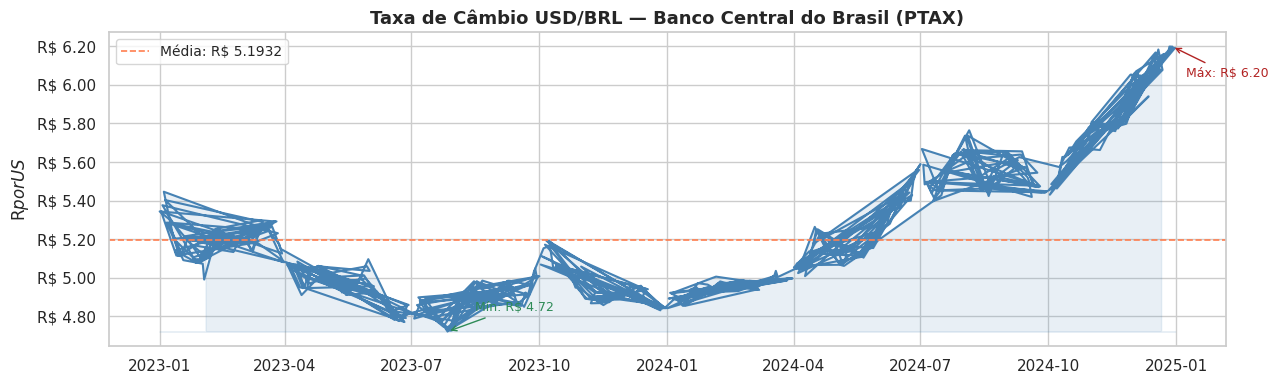

Câmbio USD/BRL | Mín: R$ 4.7202 | Máx: R$ 6.1991 | Média: R$ 5.1932
ano_mes  taxa_media
2023-01    5.197077
2023-02    5.177307
2023-03    5.217916
2023-04    5.025413
2023-05    4.980758
2023-06    4.856927
2023-07    4.800132
2023-08    4.902777
2023-09    4.937273
2023-10    5.062229
2023-11    4.901180
2023-12    4.895561
2024-01    4.906968
2024-02    4.966441
2024-03    4.981532
2024-04    5.130250
2024-05    5.132981
2024-06    5.385003
2024-07    5.540919
2024-08    5.557706
2024-09    5.538470
2024-10    5.621694
2024-11    5.809880
2024-12    6.094774


In [0]:
# Gráfico: evolução da taxa de câmbio
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(cambio['data'], cambio['taxa_brl'], linewidth=1.5, color='steelblue')
ax.fill_between(cambio['data'], cambio['taxa_brl'].min(), cambio['taxa_brl'],
                alpha=0.12, color='steelblue')
ax.axhline(cambio['taxa_brl'].mean(), color='coral', linewidth=1.2, linestyle='--',
           label=f"Média: R$ {cambio['taxa_brl'].mean():.4f}")

idx_min = cambio['taxa_brl'].idxmin()
idx_max = cambio['taxa_brl'].idxmax()
ax.annotate(f"Mín: R$ {cambio.loc[idx_min,'taxa_brl']:.2f}",
            xy=(cambio.loc[idx_min,'data'], cambio.loc[idx_min,'taxa_brl']),
            xytext=(20, 15), textcoords='offset points', fontsize=9, color='seagreen',
            arrowprops=dict(arrowstyle='->', color='seagreen'))
ax.annotate(f"Máx: R$ {cambio.loc[idx_max,'taxa_brl']:.2f}",
            xy=(cambio.loc[idx_max,'data'], cambio.loc[idx_max,'taxa_brl']),
            xytext=(10, -22), textcoords='offset points', fontsize=9, color='firebrick',
            arrowprops=dict(arrowstyle='->', color='firebrick'))

ax.set_title('Taxa de Câmbio USD/BRL — Banco Central do Brasil (PTAX)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('R$ por US$')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.2f'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
# --- resumo textual ---
cambio_m = cambio.copy()
cambio_m['ano_mes'] = cambio_m['data'].dt.strftime('%Y-%m')
resumo_cambio = cambio_m.groupby('ano_mes')['taxa_brl'].mean().reset_index()
resumo_cambio.columns = ['ano_mes', 'taxa_media']
print(f"Câmbio USD/BRL | Mín: R$ {cambio['taxa_brl'].min():.4f} | Máx: R$ {cambio['taxa_brl'].max():.4f} | Média: R$ {cambio['taxa_brl'].mean():.4f}")
print(resumo_cambio.to_string(index=False))


## 2. Enriquecimento — Base de Vendas Unificada

O enriquecimento já foi computado pelo pipeline (`data_modeling.py`) e salvo em gold_fct_vendas (Delta Lake).
O SQL executado foi uma CTE dupla em Spark SQL:
1. `custo_vigente` — subquery correlacionada que busca o `usd_price` mais recente com `start_date ≤ sale_date`
2. JOIN com silver_cambio (Delta Lake) na data da venda → calcula `custo_brl`, `lucro`, `margem_pct` por transação

Esta célula apenas carrega o artefato Gold resultante para análise.

In [0]:
# Camada Ouro e produtos ja carregados no setup via spark.table()
vendas_enriquecido = vendas_gold.copy()
produtos_df = produtos[['id_product', 'name', 'actual_category']]

print(f"Tabela Gold carregada! Transacoes: {len(vendas_enriquecido):,}")
print(vendas_enriquecido.head(3).to_string(index=False))

Tabela Gold carregada! Transacoes: 9,895
 id  id_client  id_product  qtd    total  sale_date  usd_price_vigente  taxa_brl  custo_brl     lucro  margem_pct  ano  mes ano_mes
 12         27          48   13 191573.0 2024-07-29            2940.57    5.6479  215904.59 -24331.59      -12.70 2024    7 2024-07
 18         25          27    3  47057.3 2024-11-28            3051.23    5.9871   54804.06  -7746.76      -16.46 2024   11 2024-11
 38         38          87    9 601739.0 2024-04-30           13597.70    5.1718  632921.26 -31182.26       -5.18 2024    4 2024-04


## 3. O Achado Central — A Operação Está no Vermelho

  RESULTADO OPERACIONAL — 2023 a 2024 (Câmbio Real PTAX/BCB)
  Receita total    : R$ 2.610 bilhões
  Custo total (BRL): R$ 2.749 bilhões
  Resultado        : R$ -139 milhões
  Margem geral     : -5.3%
  A OPERACAO ESTA NO VERMELHO.
  Prejuizo acumulado: R$ 139M em 2 anos.

Transações com prejuízo : 6,181 (62.5%)
Produtos com prejuízo   : 127/150


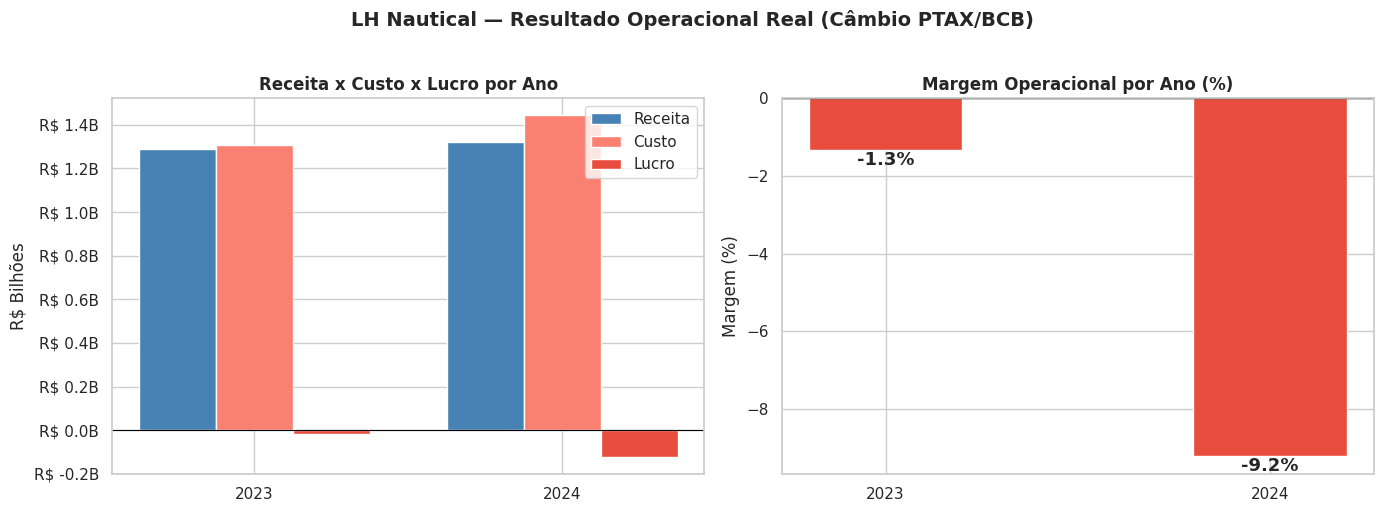

In [0]:
receita_total = vendas_enriquecido['total'].sum()
custo_total   = vendas_enriquecido['custo_brl'].sum()
lucro_total   = vendas_enriquecido['lucro'].sum()
margem_geral  = lucro_total / receita_total * 100

print('=' * 60)
print('  RESULTADO OPERACIONAL — 2023 a 2024 (Câmbio Real PTAX/BCB)')
print('=' * 60)
print(f'  Receita total    : R$ {receita_total/1e9:.3f} bilhões')
print(f'  Custo total (BRL): R$ {custo_total/1e9:.3f} bilhões')
print(f'  Resultado        : R$ {lucro_total/1e6:.0f} milhões')
print(f'  Margem geral     : {margem_geral:.1f}%')
print('=' * 60)
if margem_geral < 0:
    print(f'  A OPERACAO ESTA NO VERMELHO.')
    print(f'  Prejuizo acumulado: R$ {abs(lucro_total)/1e6:.0f}M em 2 anos.')

n_trans_neg  = (vendas_enriquecido['lucro'] < 0).sum()
n_prod_neg   = (vendas_enriquecido.groupby('id_product')['lucro'].sum() < 0).sum()
print(f'\nTransações com prejuízo : {n_trans_neg:,} ({n_trans_neg/len(vendas_enriquecido)*100:.1f}%)')
print(f'Produtos com prejuízo   : {n_prod_neg}/150')

# Barras: receita vs custo vs lucro por ano + margem
por_ano = (
    vendas_enriquecido
    .groupby('ano')
    .agg(receita=('total', 'sum'), custo=('custo_brl', 'sum'), lucro=('lucro', 'sum'))
    .assign(margem=lambda d: d['lucro'] / d['receita'] * 100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x, w = np.arange(len(por_ano)), 0.25
ax0  = axes[0]
ax0.bar(x - w, por_ano['receita']/1e9, w, label='Receita', color='steelblue')
ax0.bar(x,     por_ano['custo']/1e9,   w, label='Custo',   color='salmon')
lucro_cores = ['#2ecc71' if v >= 0 else '#e74c3c' for v in por_ano['lucro']]
ax0.bar(x + w, por_ano['lucro']/1e9,   w, label='Lucro',   color=lucro_cores)
ax0.axhline(0, color='black', linewidth=0.8)
ax0.set_xticks(x)
ax0.set_xticklabels(por_ano['ano'])
ax0.set_title('Receita x Custo x Lucro por Ano', fontweight='bold')
ax0.set_ylabel('R$ Bilhões')
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:.1f}B'))
ax0.legend()

ax1     = axes[1]
cores_m = ['#2ecc71' if m >= 0 else '#e74c3c' for m in por_ano['margem']]
bars_m  = ax1.bar(por_ano['ano'].astype(str), por_ano['margem'], color=cores_m, width=0.4)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('Margem Operacional por Ano (%)', fontweight='bold')
ax1.set_ylabel('Margem (%)')
for bar, m in zip(bars_m, por_ano['margem']):
    ypos = bar.get_height() + 0.1 if m >= 0 else bar.get_height() - 0.5
    ax1.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{m:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

plt.suptitle('LH Nautical — Resultado Operacional Real (Câmbio PTAX/BCB)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [0]:
# Check de reconciliacao financeira (controle de qualidade analitica)
delta = receita_total - custo_total - lucro_total
ok_reconciliacao = np.isclose(delta, 0, atol=1e-2)
print(f'Reconciliacao receita - custo - lucro: delta={delta:.4f} | OK={ok_reconciliacao}')
assert ok_reconciliacao, 'Falha na reconciliacao financeira: receita - custo != lucro'

Reconciliacao receita - custo - lucro: delta=-0.0100 | OK=True


## 4. Evolução Mensal — O Câmbio Corroeu as Margens

Três séries no mesmo gráfico:
- **Barras:** receita vs custo mensais (BRL)
- **Linha vermelha:** margem operacional (%)
- **Linha laranja:** taxa de câmbio média do mês

Expectativa: à medida que o dólar sobe (linha laranja), a margem cai (linha vermelha).

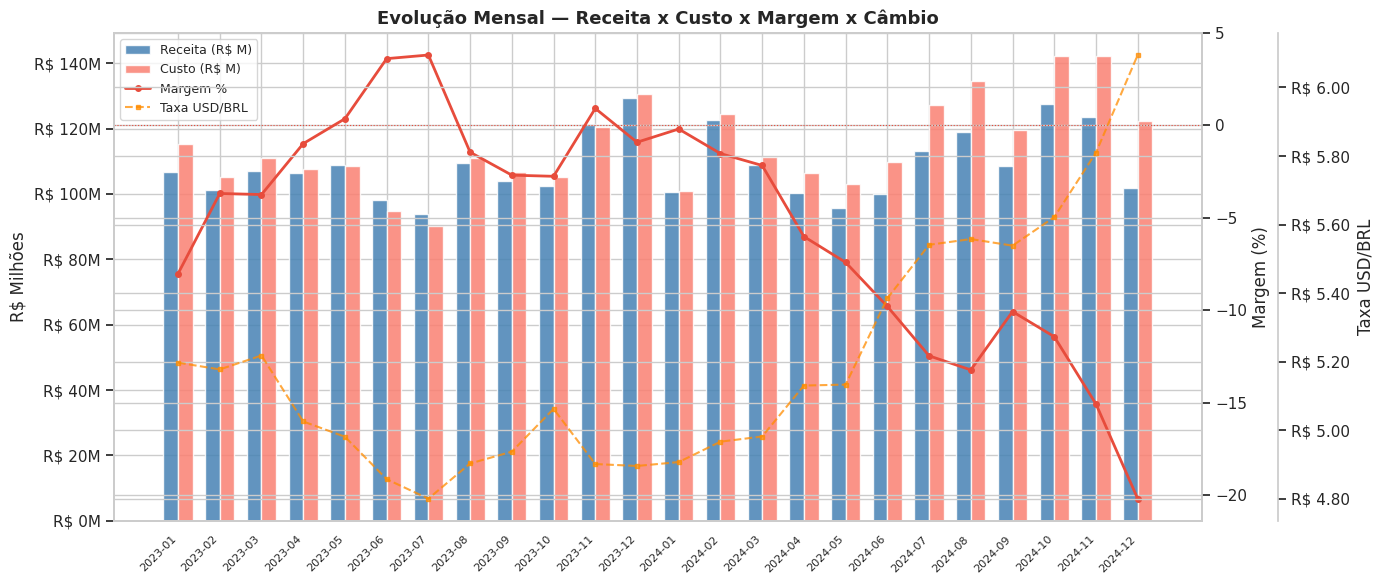

=== EVOLUÇÃO MENSAL — Receita x Custo x Margem x Câmbio ===
ano_mes receita  custo  lucro margem taxa_brl
2023-01  106.8M 115.4M  -8.6M  -8.0%  R$ 5.20
2023-02  101.3M 105.1M  -3.7M  -3.7%  R$ 5.18
2023-03  106.9M 110.9M  -4.0M  -3.7%  R$ 5.22
2023-04  106.5M 107.6M  -1.0M  -1.0%  R$ 5.03
2023-05  108.9M 108.5M   0.4M   0.4%  R$ 4.98
2023-06   98.2M  94.7M   3.5M   3.6%  R$ 4.86
2023-07   93.8M  90.2M   3.6M   3.8%  R$ 4.80
2023-08  109.5M 111.1M  -1.6M  -1.4%  R$ 4.90
2023-09  103.8M 106.6M  -2.8M  -2.7%  R$ 4.94
2023-10  102.4M 105.2M  -2.8M  -2.8%  R$ 5.06
2023-11  121.5M 120.3M   1.1M   0.9%  R$ 4.90
2023-12  129.2M 130.4M  -1.2M  -0.9%  R$ 4.90
2024-01  100.6M 100.8M  -0.2M  -0.2%  R$ 4.91
2024-02  122.6M 124.5M  -1.9M  -1.5%  R$ 4.97
2024-03  108.9M 111.2M  -2.4M  -2.2%  R$ 4.98
2024-04  100.3M 106.3M  -6.0M  -6.0%  R$ 5.13
2024-05   95.8M 102.9M  -7.1M  -7.4%  R$ 5.13
2024-06   99.8M 109.6M  -9.8M  -9.8%  R$ 5.39
2024-07  113.1M 127.1M -14.1M -12.5%  R$ 5.54
2024-08  118.9M 134.

In [0]:
mensal = (
    vendas_enriquecido
    .groupby('ano_mes')
    .agg(receita=('total', 'sum'), custo=('custo_brl', 'sum'), lucro=('lucro', 'sum'))
    .assign(margem=lambda d: d['lucro'] / d['receita'] * 100)
    .reset_index()
)

# Taxa média mensal
cambio_temp = cambio.copy()
cambio_temp['ano_mes'] = cambio_temp['data'].dt.strftime('%Y-%m')
taxa_mensal = cambio_temp.groupby('ano_mes')['taxa_brl'].mean().reset_index()
mensal = mensal.merge(taxa_mensal, on='ano_mes', how='left')

fig, ax1 = plt.subplots(figsize=(14, 6))
x = range(len(mensal))
w = 0.35

ax1.bar([i - w/2 for i in x], mensal['receita']/1e6, w,
        label='Receita (R$ M)', color='steelblue', alpha=0.85)
ax1.bar([i + w/2 for i in x], mensal['custo']/1e6, w,
        label='Custo (R$ M)',   color='salmon',    alpha=0.85)
ax1.set_ylabel('R$ Milhões')
ax1.set_title('Evolução Mensal — Receita x Custo x Margem x Câmbio',
              fontweight='bold', fontsize=13)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:.0f}M'))

ax2 = ax1.twinx()
ax2.plot(x, mensal['margem'], color='#e74c3c', linewidth=2,
         marker='o', markersize=4, label='Margem %', zorder=5)
ax2.axhline(0, color='#e74c3c', linewidth=0.8, linestyle=':')
ax2.set_ylabel('Margem (%)')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 55))
ax3.plot(x, mensal['taxa_brl'], color='darkorange', linewidth=1.5,
         linestyle='--', marker='s', markersize=3, label='Taxa USD/BRL', alpha=0.75)
ax3.set_ylabel('Taxa USD/BRL')
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.2f'))

ax1.set_xticks(list(x))
ax1.set_xticklabels(mensal['ano_mes'], rotation=45, ha='right', fontsize=8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/img/evolucao_mensal.png', dpi=150, bbox_inches='tight')
plt.show()
# --- resumo textual ---
print('=== EVOLUÇÃO MENSAL — Receita x Custo x Margem x Câmbio ===')
print(mensal.assign(
    receita =lambda d: (d['receita']/1e6).map('{:.1f}M'.format),
    custo   =lambda d: (d['custo']/1e6).map('{:.1f}M'.format),
    lucro   =lambda d: (d['lucro']/1e6).map('{:.1f}M'.format),
    margem  =lambda d: d['margem'].map('{:.1f}%'.format),
    taxa_brl=lambda d: d['taxa_brl'].map('R$ {:.2f}'.format),
).to_string(index=False))

## 5. Rentabilidade por Produto

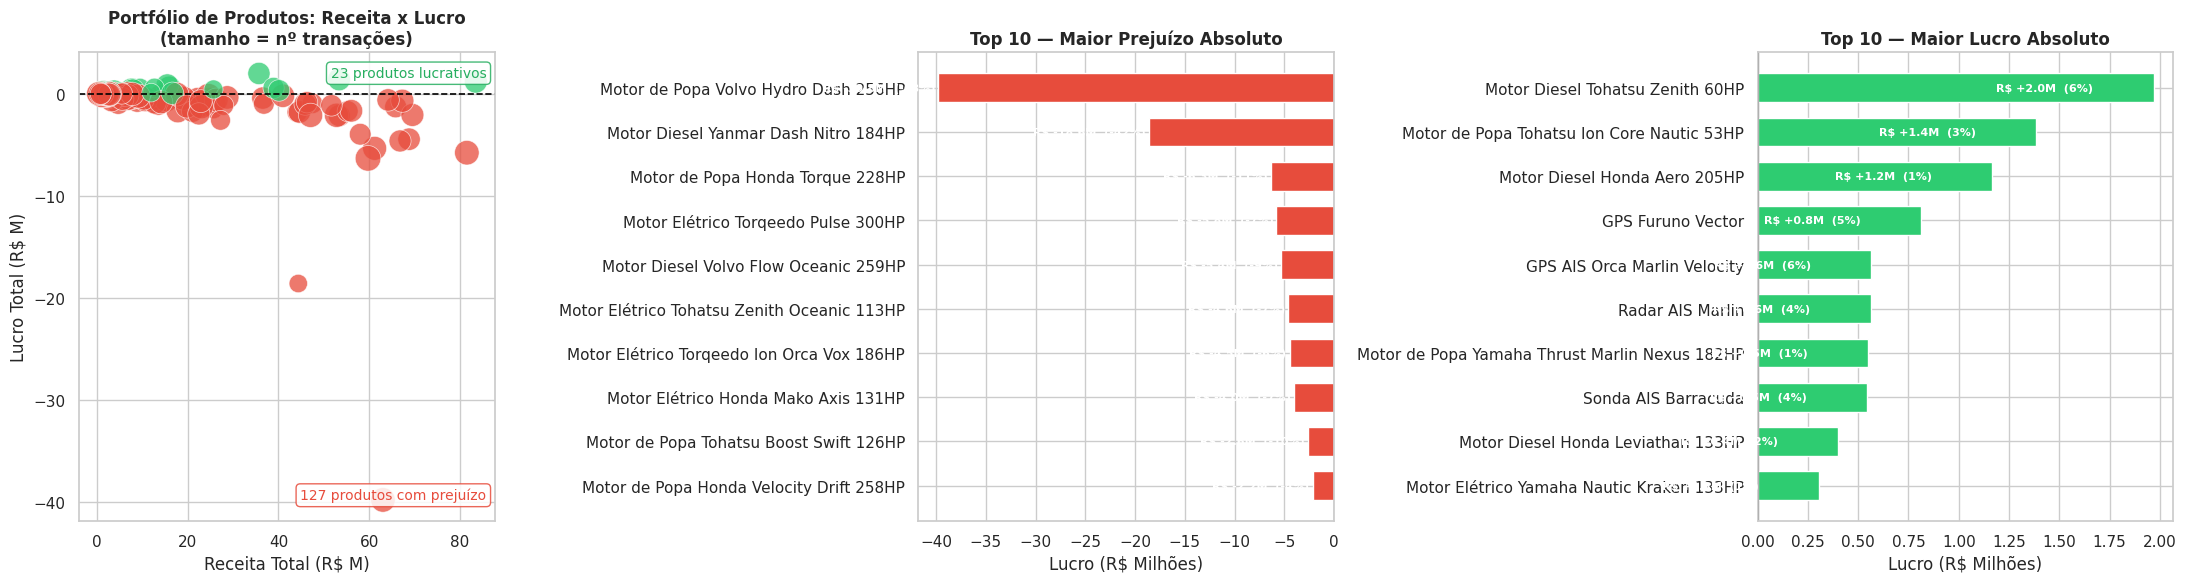


=== TOP 10 PRODUTOS MAIS RENTAVEIS (margem %) — minimo 20 transacoes ===
                               name actual_category  n_trans  receita_total  custo_total  lucro_total  margem_pct
Boia de Arqueamento Danforth Torque       ancoragem       70      837046.15    767213.84     69832.31         8.3
            Corrente Danforth Hydro       ancoragem       73     1388455.25   1283903.43    104551.82         7.5
       GPS AIS Orca Marlin Velocity     eletrônicos       47     9471755.80   8906718.07    565037.73         6.0
                 Radar Simrad Boost     eletrônicos       67     3774383.00   3558874.10    215508.90         5.7
   Motor Diesel Tohatsu Zenith 60HP       propulsão       64    35699451.80  33730954.58   1968497.22         5.5
                  GPS Furuno Vector     eletrônicos       67    15493523.15  14680126.68    813396.47         5.2
                Sonda AIS Barracuda     eletrônicos       50    12661193.95  12117828.19    543365.76         4.3
             T

In [0]:
lucro_produto = (
    vendas_enriquecido
    .merge(produtos_df, left_on='id_product', right_on='id_product')
    .groupby(['id_product', 'name', 'actual_category'])
    .agg(
        receita_total=('total',     'sum'),
        custo_total  =('custo_brl', 'sum'),
        lucro_total  =('lucro',     'sum'),
        n_trans      =('id',        'count')
    )
    .reset_index()
    .assign(margem_pct=lambda d: (d['lucro_total'] / d['receita_total'] * 100).round(1))
)

n_pos = (lucro_produto['lucro_total'] >= 0).sum()
n_neg = (lucro_produto['lucro_total'] <  0).sum()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Scatter: receita vs lucro ---
cores_sc = ['#e74c3c' if v < 0 else '#2ecc71' for v in lucro_produto['lucro_total']]
ax0 = axes[0]
ax0.scatter(lucro_produto['receita_total']/1e6, lucro_produto['lucro_total']/1e6,
            c=cores_sc, s=lucro_produto['n_trans']*4, alpha=0.75,
            edgecolors='white', linewidth=0.5)
ax0.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax0.set_xlabel('Receita Total (R$ M)')
ax0.set_ylabel('Lucro Total (R$ M)')
ax0.set_title('Portfólio de Produtos: Receita x Lucro\n(tamanho = nº transações)',
              fontweight='bold')
# Labels em cantos opostos, com caixa de fundo para legibilidade
ax0.text(0.98, 0.04, f'{n_neg} produtos com prejuízo',
         transform=ax0.transAxes, va='bottom', ha='right', color='#e74c3c', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#e74c3c', alpha=0.85))
ax0.text(0.98, 0.97, f'{n_pos} produtos lucrativos',
         transform=ax0.transAxes, va='top', ha='right', color='#27ae60', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#27ae60', alpha=0.85))

# --- Top 10 maior prejuízo ---
top_prej = lucro_produto.nsmallest(10, 'lucro_total')
ax1 = axes[1]
bars = ax1.barh(top_prej['name'], top_prej['lucro_total']/1e6, color='#e74c3c', height=0.65)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('Top 10 — Maior Prejuízo Absoluto', fontweight='bold')
ax1.set_xlabel('Lucro (R$ Milhões)')
ax1.invert_yaxis()
for bar, row in zip(bars, top_prej.itertuples()):
    ax1.text(bar.get_width() - 0.3, bar.get_y() + bar.get_height()/2,
             f'R$ {row.lucro_total/1e6:.1f}M  ({row.margem_pct:.0f}%)',
             va='center', ha='right', fontsize=8, color='white', fontweight='bold')

# --- Top 10 maior lucro ---
top_lucro = lucro_produto.nlargest(10, 'lucro_total')
ax2 = axes[2]
bars2 = ax2.barh(top_lucro['name'], top_lucro['lucro_total']/1e6, color='#2ecc71', height=0.65)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Top 10 — Maior Lucro Absoluto', fontweight='bold')
ax2.set_xlabel('Lucro (R$ Milhões)')
ax2.invert_yaxis()
for bar, row in zip(bars2, top_lucro.itertuples()):
    ax2.text(bar.get_width() - 0.3, bar.get_y() + bar.get_height()/2,
             f'R$ +{row.lucro_total/1e6:.1f}M  ({row.margem_pct:.0f}%)',
             va='center', ha='right', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== TOP 10 PRODUTOS MAIS RENTAVEIS (margem %) — minimo 20 transacoes ===')
print(
    lucro_produto[lucro_produto['n_trans'] >= 20]
    .nlargest(10, 'margem_pct')
    [['name','actual_category','n_trans','receita_total','custo_total','lucro_total','margem_pct']]
    .to_string(index=False)
)

### 5.1 Análise de Pareto — Concentração do Prejuízo

Quais produtos concentram a maior parte da perda?

Barras: prejuízo absoluto por produto (R$ M), do pior ao menos pior.  
Curva azul: percentual acumulado do prejuízo total.  
A linha tracejada em 80% revela quantos produtos são responsáveis pela maior parte do problema — o foco prioritário para reajuste de preços.

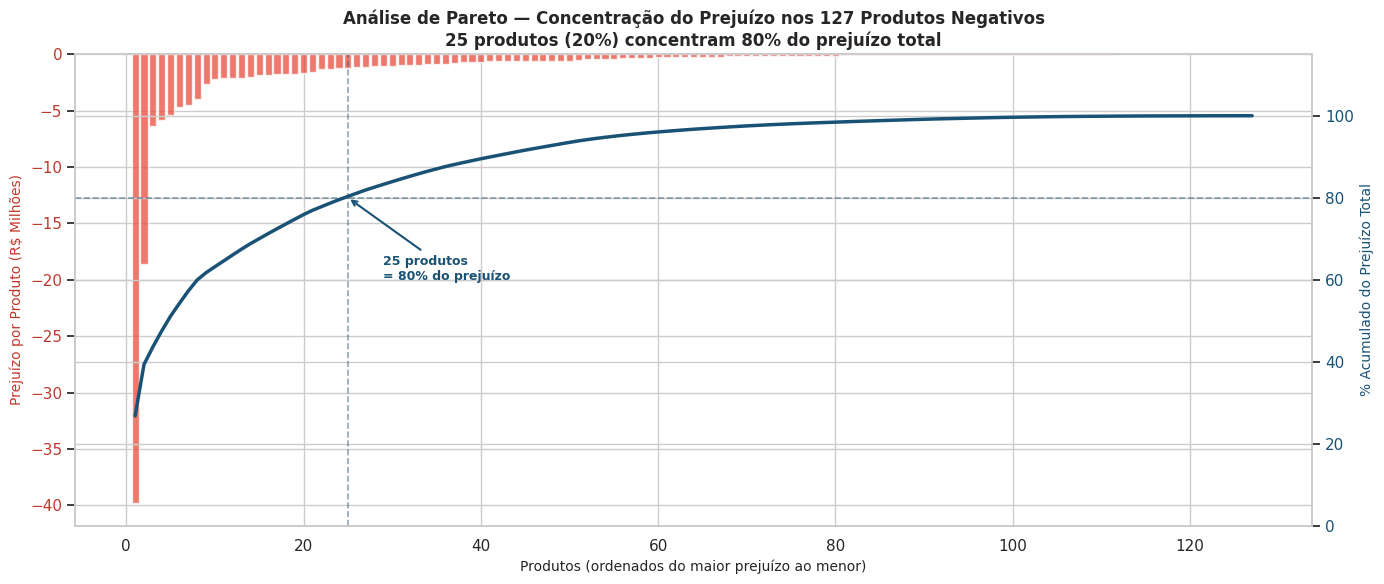

Produtos negativos        : 127/150
Prejuízo bruto (negativos): R$ 149M
Ganho (23 prod. positivos): R$ +10M
Resultado líquido         : R$ -139M  ← o R$-139M do relatório
Produtos para 80% da perda: 25 (20% dos negativos)

Insight: corrigir 25 produtos elimina 80% do prejuízo bruto de R$ 149M.


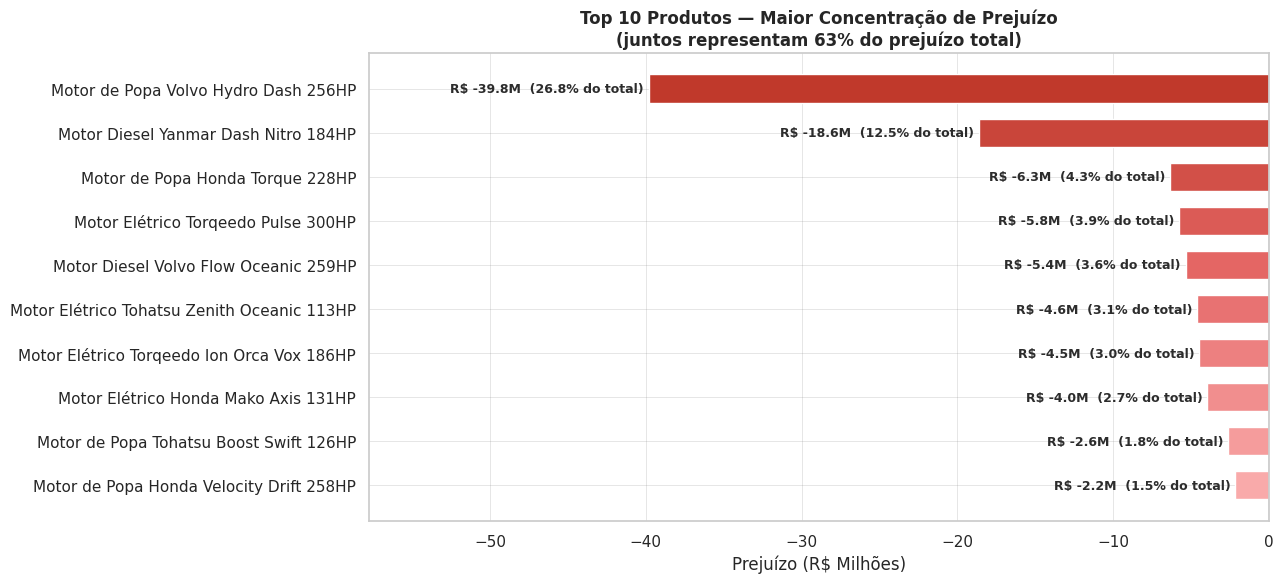

In [0]:
# Pareto do Prejuízo — quais produtos concentram a maior parte da perda?
produtos_negativos = (
    lucro_produto[lucro_produto['lucro_total'] < 0]
    .sort_values('lucro_total')       # do pior para o menos pior
    .reset_index(drop=True)
)

prejuizo_total = produtos_negativos['lucro_total'].sum()
produtos_negativos['prejuizo_acum_pct'] = (
    produtos_negativos['lucro_total'].cumsum() / prejuizo_total * 100
)
produtos_negativos['rank'] = range(1, len(produtos_negativos) + 1)

# Número de produtos que concentram 80% do prejuízo
idx_80 = int((produtos_negativos['prejuizo_acum_pct'] >= 80).idxmax())
n_80   = idx_80 + 1

fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras de prejuízo por produto
ax1.bar(
    produtos_negativos['rank'],
    produtos_negativos['lucro_total'] / 1e6,
    color='#e74c3c', alpha=0.75, width=0.8
)
ax1.set_xlabel('Produtos (ordenados do maior prejuízo ao menor)', fontsize=10)
ax1.set_ylabel('Prejuízo por Produto (R$ Milhões)', color='#c0392b', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_title(
    f'Análise de Pareto — Concentração do Prejuízo nos {len(produtos_negativos)} Produtos Negativos\n'
    f'{n_80} produtos ({n_80 / len(produtos_negativos) * 100:.0f}%) concentram 80% do prejuízo total',
    fontsize=12, fontweight='bold'
)

# Curva de Pareto (% acumulado)
ax2 = ax1.twinx()
ax2.plot(
    produtos_negativos['rank'],
    produtos_negativos['prejuizo_acum_pct'],
    color='#1a5276', linewidth=2.5, zorder=5
)
ax2.axhline(80, color='#1a5276', linestyle='--', linewidth=1.2, alpha=0.5)
ax2.axvline(n_80, color='#1a5276', linestyle='--', linewidth=1.2, alpha=0.5)
ax2.set_ylabel('% Acumulado do Prejuízo Total', color='#1a5276', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#1a5276')
ax2.set_ylim(0, 115)

ax2.annotate(
    f'{n_80} produtos\n= 80% do prejuízo',
    xy=(n_80, 80),
    xytext=(n_80 + 4, 60),
    fontsize=9, fontweight='bold', color='#1a5276',
    arrowprops=dict(arrowstyle='->', color='#1a5276', lw=1.5)
)

plt.tight_layout()
plt.savefig("../assets/img/pareto_prejuizo.png", dpi=150, bbox_inches="tight")
plt.show()

ganho_positivos = lucro_produto[lucro_produto['lucro_total'] > 0]['lucro_total'].sum()
print(f'Produtos negativos        : {len(produtos_negativos)}/150')
print(f'Prejuízo bruto (negativos): R$ {abs(prejuizo_total/1e6):.0f}M')
n_pos = len(lucro_produto[lucro_produto['lucro_total'] > 0])
print(f'Ganho ({n_pos} prod. positivos): R$ +{ganho_positivos/1e6:.0f}M')
print(f'Resultado líquido         : R$ {(prejuizo_total + ganho_positivos)/1e6:.0f}M  ← o R$-139M do relatório')
print(f'Produtos para 80% da perda: {n_80} ({n_80/len(produtos_negativos)*100:.0f}% dos negativos)')
print(f'\nInsight: corrigir {n_80} produtos elimina 80% do prejuízo bruto de R$ {abs(prejuizo_total/1e6):.0f}M.')

# --- Gráfico: Top 10 que concentram o prejuízo (para o relatório) ---
top10_pareto = produtos_negativos.head(10).copy()
top10_pareto['pct_prejuizo'] = (top10_pareto['lucro_total'] / prejuizo_total * 100).round(1)

fig2, ax_p = plt.subplots(figsize=(13, 6))
ax_p.grid(axis='both', color='gray', alpha=0.2, linewidth=0.7)
ax_p.set_axisbelow(True)
cores_top10 = ['#c0392b', '#c9453a', '#d25048', '#db5b56', '#e46664',
               '#e87272', '#ed8080', '#f18e8e', '#f59c9c', '#f9aaaa']
bars_p = ax_p.barh(
    top10_pareto['name'],
    top10_pareto['lucro_total'] / 1e6,
    color=cores_top10[:len(top10_pareto)],
    height=0.65
)
ax_p.axvline(0, color='black', linewidth=0.8)
ax_p.set_title(
    f'Top 10 Produtos — Maior Concentração de Prejuízo\n'
    f'(juntos representam {top10_pareto["pct_prejuizo"].sum():.0f}% do prejuízo total)',
    fontweight='bold'
)
ax_p.set_xlabel('Prejuízo (R$ Milhões)')
ax_p.invert_yaxis()
# Extende o eixo x para dar espaço ao texto fora das barras
min_val = top10_pareto['lucro_total'].min() / 1e6
ax_p.set_xlim(min_val * 1.45, 0)

for bar, row in zip(bars_p, top10_pareto.itertuples()):
    ax_p.text(
        bar.get_width() - 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {row.lucro_total/1e6:.1f}M  ({row.pct_prejuizo:.1f}% do total)',
        va='center', ha='right', fontsize=9, color='#2c2c2c', fontweight='bold'
    )
plt.tight_layout()
plt.savefig("../assets/img/top10_prejuizo.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Break-even Cambial — A que Taxa Cada Produto Vira Prejuízo?

**Cálculo:** `taxa_breakeven = preço_médio_BRL_por_unidade ÷ custo_médio_USD_por_unidade`

- `taxa_breakeven < taxa_atual` → produto **já está** no vermelho
- `taxa_breakeven < taxa_atual + 0,50` → produto em **zona de risco** (pequena alta do dólar o derruba)

Este indicador responde: **qual reajuste de preço é necessário antes da próxima alta cambial?**

Taxa de cambio ao final do periodo: R$ 6.1900 (dez/2024)

Produtos com break-even abaixo da taxa atual (R$ 6.19):
  No vermelho agora   : 150
  Em risco (+R$ 0,50) : 0
  Seguros             : 0


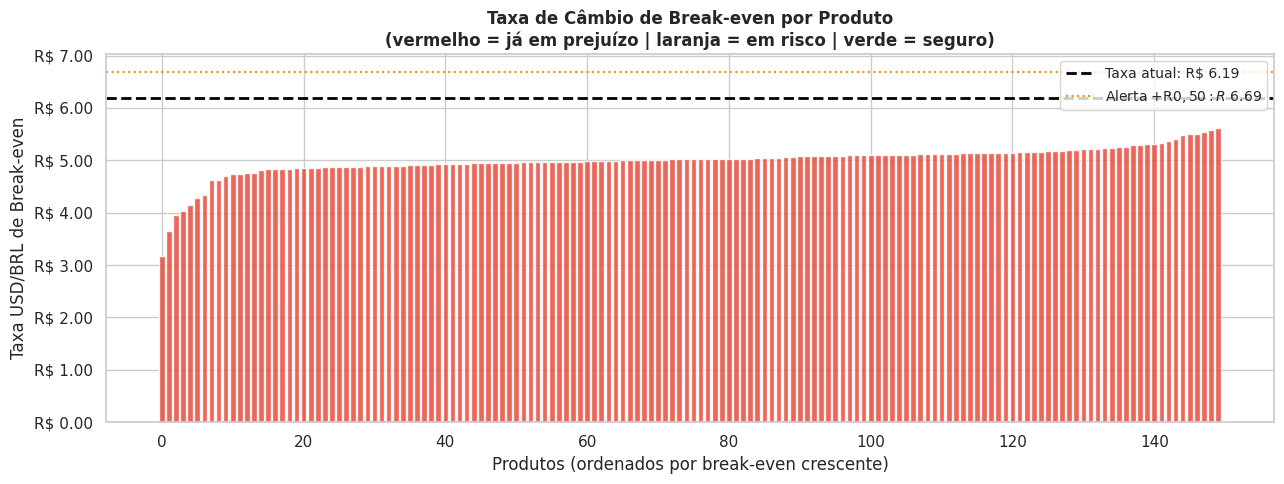

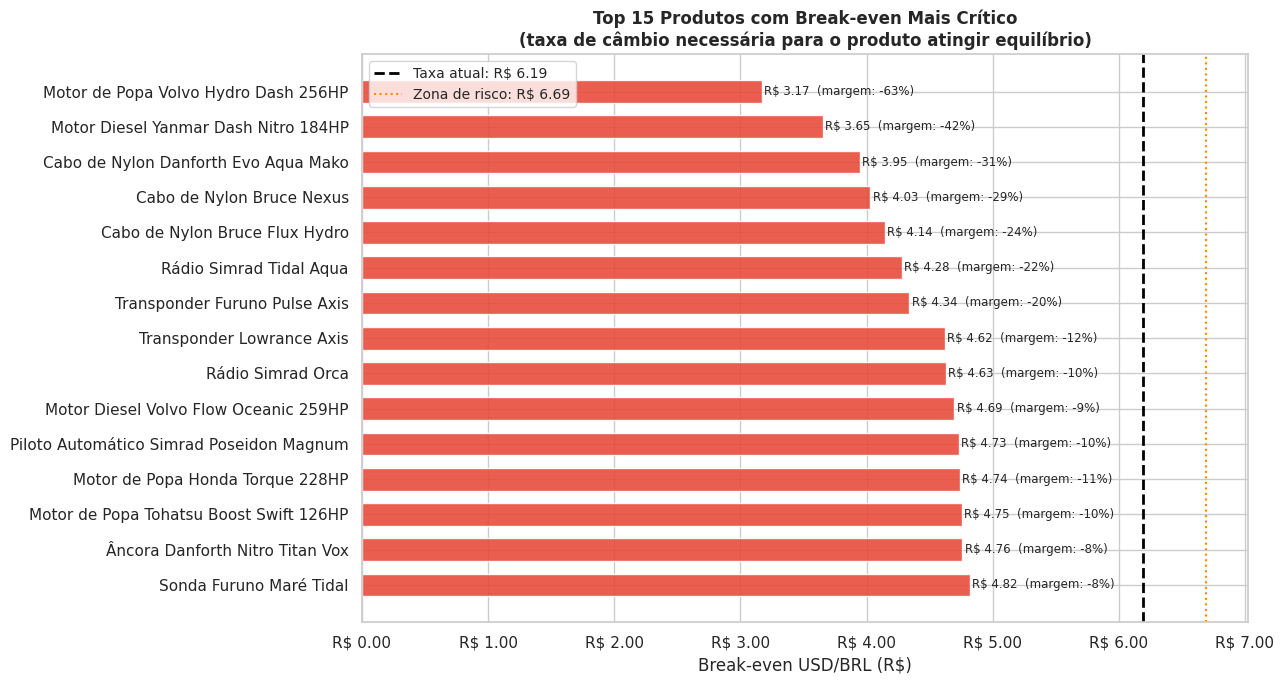

In [0]:
# preco_unit_brl = total / qtd (preço de venda por unidade em BRL)
vendas_enriquecido['preco_unit_brl'] = vendas_enriquecido['total'] / vendas_enriquecido['qtd']

breakeven = (
    vendas_enriquecido
    .merge(produtos_df, left_on='id_product', right_on='id_product')
    .groupby(['id_product', 'name', 'actual_category'])
    .agg(
        preco_unit_brl_medio=('preco_unit_brl',    'mean'),
        custo_unit_usd_medio=('usd_price_vigente', 'mean'),
        receita_total       =('total',             'sum'),
        lucro_total         =('lucro',             'sum')
    )
    .reset_index()
    .assign(
        taxa_breakeven=lambda d: (d['preco_unit_brl_medio'] / d['custo_unit_usd_medio']).round(4),
        margem_pct    =lambda d: (d['lucro_total'] / d['receita_total'] * 100).round(1)
    )
    .sort_values('taxa_breakeven')
    .reset_index(drop=True)
)

taxa_atual = 6.19  # R$6,19 — referência do relatório
n_vermelho = (breakeven['taxa_breakeven'] < taxa_atual).sum()
n_risco    = breakeven['taxa_breakeven'].between(taxa_atual, taxa_atual + 0.5).sum()
n_seguro   = (breakeven['taxa_breakeven'] > taxa_atual + 0.5).sum()

print(f'Taxa de cambio ao final do periodo: R$ {taxa_atual:.4f} (dez/2024)')
print(f'\nProdutos com break-even abaixo da taxa atual (R$ {taxa_atual:.2f}):')
print(f'  No vermelho agora   : {n_vermelho}')
print(f'  Em risco (+R$ 0,50) : {n_risco}')
print(f'  Seguros             : {n_seguro}')

# --- Histograma de break-even (todos os produtos) ---
fig, ax = plt.subplots(figsize=(13, 5))
cores_be = [
    '#e74c3c' if t < taxa_atual
    else '#f39c12' if t < taxa_atual + 0.5
    else '#2ecc71'
    for t in breakeven['taxa_breakeven']
]
ax.bar(range(len(breakeven)), breakeven['taxa_breakeven'],
       color=cores_be, width=0.8, alpha=0.85)
ax.axhline(taxa_atual, color='black', linewidth=2, linestyle='--',
           label=f'Taxa atual: R$ {taxa_atual:.2f}')
ax.axhline(taxa_atual + 0.5, color='darkorange', linewidth=1.5, linestyle=':',
           label=f'Alerta +R$0,50: R$ {taxa_atual+0.5:.2f}')
ax.set_title('Taxa de Câmbio de Break-even por Produto\n'
             '(vermelho = já em prejuízo | laranja = em risco | verde = seguro)',
             fontweight='bold')
ax.set_xlabel('Produtos (ordenados por break-even crescente)')
ax.set_ylabel('Taxa USD/BRL de Break-even')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.2f'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# --- Top 15 break-even mais críticos: gráfico para o relatório ---
top15_be = breakeven.head(15).copy()

fig2, ax2 = plt.subplots(figsize=(13, 7))
cores_top15 = [
    '#e74c3c' if t < taxa_atual else '#f39c12'
    for t in top15_be['taxa_breakeven']
]
bars_be = ax2.barh(top15_be['name'], top15_be['taxa_breakeven'],
                   color=cores_top15, height=0.65, alpha=0.9)
ax2.axvline(taxa_atual, color='black', linewidth=2, linestyle='--',
            label=f'Taxa atual: R$ {taxa_atual:.2f}')
ax2.axvline(taxa_atual + 0.5, color='darkorange', linewidth=1.5, linestyle=':',
            label=f'Zona de risco: R$ {taxa_atual+0.5:.2f}')
ax2.set_title(
    'Top 15 Produtos com Break-even Mais Crítico\n'
    '(taxa de câmbio necessária para o produto atingir equilíbrio)',
    fontweight='bold'
)
ax2.set_xlabel('Break-even USD/BRL (R$)')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.2f'))
ax2.invert_yaxis()
ax2.legend(fontsize=10)
for bar, row in zip(bars_be, top15_be.itertuples()):
    ax2.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {row.taxa_breakeven:.2f}  (margem: {row.margem_pct:.0f}%)',
        va='center', ha='left', fontsize=8.5
    )
plt.tight_layout()
plt.savefig("../assets/img/break_even_cambial.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Rentabilidade por Categoria

actual_category receita_total custo_total lucro_total  n_trans  n_produtos margem_pct pct_receita
      propulsão      R$ 2.08B    R$ 2.20B    R$ -123M     3217          50      -5.9%       79.5%
    eletrônicos      R$ 0.46B    R$ 0.48B     R$ -14M     3340          50      -3.0%       17.8%
      ancoragem      R$ 0.07B    R$ 0.07B      R$ -2M     3338          50      -3.6%        2.7%


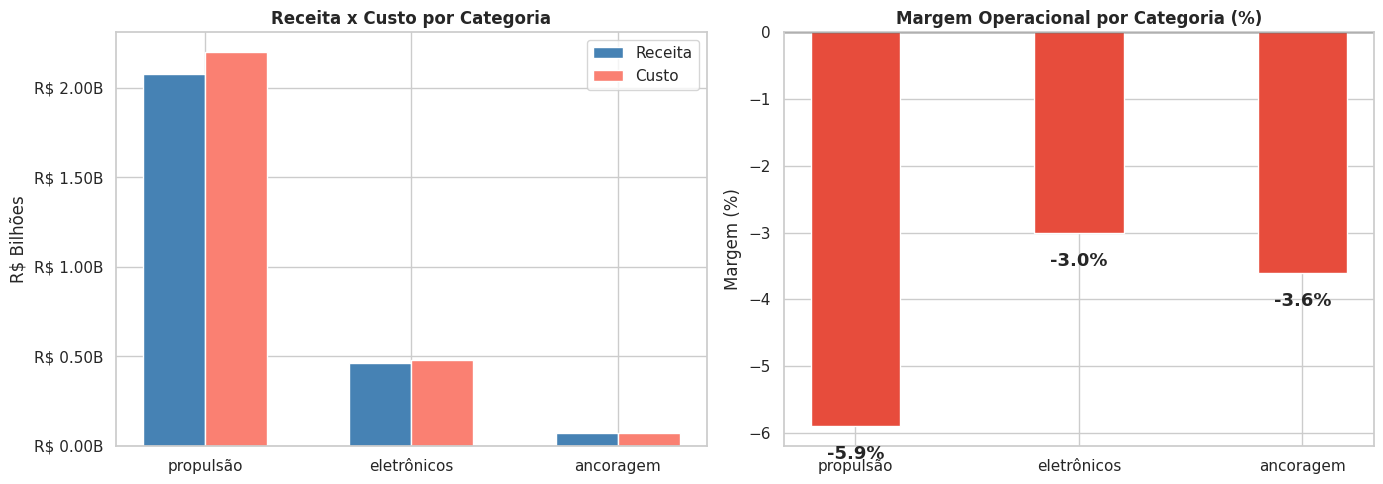

In [0]:
cat_df = (
    vendas_enriquecido
    .merge(produtos_df, left_on='id_product', right_on='id_product')
    .groupby('actual_category')
    .agg(
        receita_total=('total',     'sum'),
        custo_total  =('custo_brl', 'sum'),
        lucro_total  =('lucro',     'sum'),
        n_trans      =('id',        'count'),
        n_produtos   =('id_product','nunique')
    )
    .reset_index()
    .assign(
        margem_pct =lambda d: (d['lucro_total'] / d['receita_total'] * 100).round(1),
        pct_receita=lambda d: (d['receita_total'] / d['receita_total'].sum() * 100).round(1)
    )
    .sort_values('receita_total', ascending=False)
)

print(cat_df.assign(
    receita_total=lambda d: (d['receita_total']/1e9).map('R$ {:.2f}B'.format),
    custo_total  =lambda d: (d['custo_total']/1e9).map('R$ {:.2f}B'.format),
    lucro_total  =lambda d: (d['lucro_total']/1e6).map('R$ {:.0f}M'.format),
    margem_pct   =lambda d: d['margem_pct'].map('{:.1f}%'.format),
    pct_receita  =lambda d: d['pct_receita'].map('{:.1f}%'.format),
).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x, w = np.arange(len(cat_df)), 0.3
ax0  = axes[0]
ax0.bar(x - w/2, cat_df['receita_total']/1e9, w, label='Receita', color='steelblue')
ax0.bar(x + w/2, cat_df['custo_total']/1e9,   w, label='Custo',   color='salmon')
ax0.set_xticks(x)
ax0.set_xticklabels(cat_df['actual_category'])
ax0.set_title('Receita x Custo por Categoria', fontweight='bold')
ax0.set_ylabel('R$ Bilhões')
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:.2f}B'))
ax0.legend()

cores_cat = ['#2ecc71' if m >= 0 else '#e74c3c' for m in cat_df['margem_pct']]
ax1 = axes[1]
bars = ax1.bar(cat_df['actual_category'], cat_df['margem_pct'],
               color=cores_cat, width=0.4)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('Margem Operacional por Categoria (%)', fontweight='bold')
ax1.set_ylabel('Margem (%)')
for bar, m in zip(bars, cat_df['margem_pct']):
    ypos = bar.get_height() + 0.2 if m >= 0 else bar.get_height() - 0.5
    ax1.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{m:.1f}%', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig("../assets/img/receita_por_categoria.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Faturamento Histórico (Contexto de Volume)

Análise de volume e crescimento de receita bruta — o que parecia positivo antes de considerar o câmbio.

=== VOLUME DE FATURAMENTO POR ANO (receita bruta) ===
 ano  transacoes  receita_brl  ticket_medio  var_pct
2023        4991 1.288827e+09     258230.27      NaN
2024        4904 1.321452e+09     269464.16      2.5
Nota: crescimento de receita bruta mascara a deterioracao de margem.


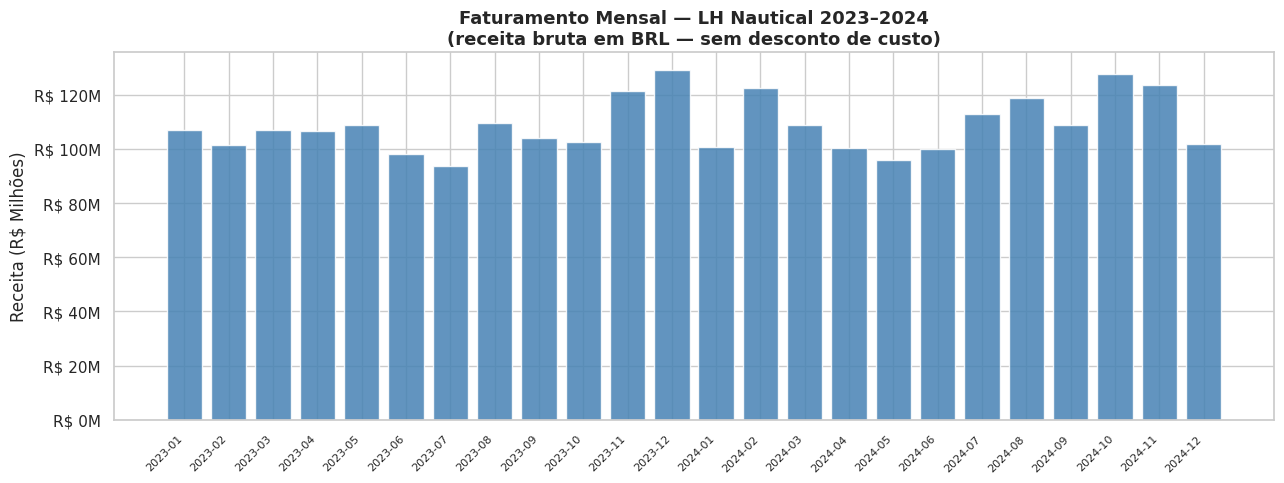

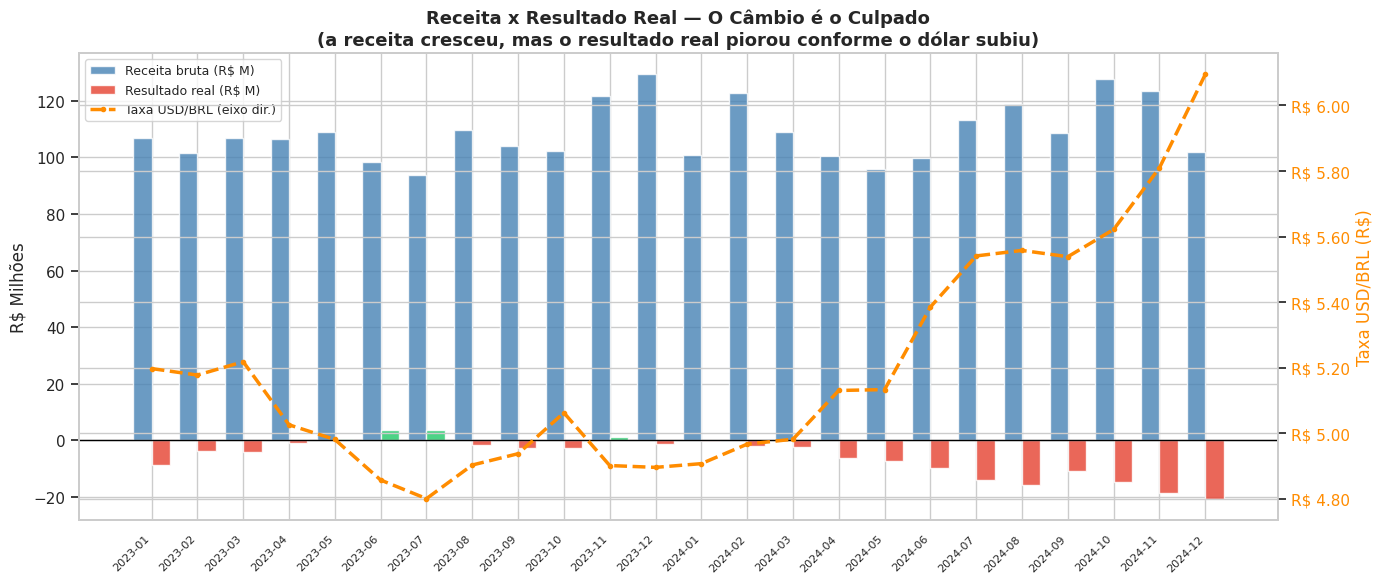

In [0]:
fat_mensal = spark.sql("""
    SELECT
        DATE_FORMAT(sale_date, 'yyyy-MM') AS ano_mes,
        COUNT(*)                      AS transacoes,
        ROUND(SUM(total), 2)          AS receita_brl,
        ROUND(AVG(total), 2)          AS ticket_medio
    FROM workspace.lh_nautical.gold_fct_vendas
    GROUP BY DATE_FORMAT(sale_date, 'yyyy-MM')
    ORDER BY 1
""").toPandas()

fat_anual = spark.sql("""
    SELECT
        YEAR(sale_date)      AS ano,
        COUNT(*)             AS transacoes,
        ROUND(SUM(total), 2) AS receita_brl,
        ROUND(AVG(total), 2) AS ticket_medio
    FROM workspace.lh_nautical.gold_fct_vendas
    GROUP BY YEAR(sale_date)
    ORDER BY 1
""").toPandas()
fat_anual['var_pct'] = fat_anual['receita_brl'].pct_change().mul(100).round(1)

print('=== VOLUME DE FATURAMENTO POR ANO (receita bruta) ===')
print(fat_anual.to_string(index=False))
print('Nota: crescimento de receita bruta mascara a deterioracao de margem.')

# --- Gráfico 1: faturamento bruto mensal ---
fig1, ax_fat = plt.subplots(figsize=(13, 5))
ax_fat.bar(fat_mensal['ano_mes'], fat_mensal['receita_brl']/1e6,
           color='steelblue', alpha=0.85)
ax_fat.set_title('Faturamento Mensal — LH Nautical 2023–2024\n'
                 '(receita bruta em BRL — sem desconto de custo)',
                 fontsize=13, fontweight='bold')
ax_fat.set_ylabel('Receita (R$ Milhões)')
ax_fat.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:.0f}M'))
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# --- Gráfico 2: receita vs resultado real + câmbio — quem é o culpado ---
lucro_mensal = (
    vendas_enriquecido
    .assign(ano_mes=vendas_enriquecido['sale_date'].dt.to_period('M').astype(str))
    .groupby('ano_mes')
    .agg(receita=('total', 'sum'), resultado=('lucro', 'sum'))
    .reset_index()
    .merge(
        cambio
        .assign(ano_mes=cambio['data'].dt.to_period('M').astype(str))
        .groupby('ano_mes')['taxa_brl'].mean()
        .reset_index(),
        on='ano_mes', how='left'
    )
)

fig2, ax_r = plt.subplots(figsize=(14, 6))
x = range(len(lucro_mensal))
w = 0.4

ax_r.bar([i - w/2 for i in x], lucro_mensal['receita']/1e6,
         width=w, color='steelblue', alpha=0.8, label='Receita bruta (R$ M)')
ax_r.bar([i + w/2 for i in x], lucro_mensal['resultado']/1e6,
         width=w,
         color=['#e74c3c' if v < 0 else '#2ecc71' for v in lucro_mensal['resultado']],
         alpha=0.85, label='Resultado real (R$ M)')
ax_r.axhline(0, color='black', linewidth=1)
ax_r.set_ylabel('R$ Milhões')
ax_r.set_title(
    'Receita x Resultado Real — O Câmbio é o Culpado\n'
    '(a receita cresceu, mas o resultado real piorou conforme o dólar subiu)',
    fontsize=13, fontweight='bold'
)
ax_r.set_xticks(list(x))
ax_r.set_xticklabels(lucro_mensal['ano_mes'], rotation=45, ha='right', fontsize=8)

ax_c = ax_r.twinx()
ax_c.plot(list(x), lucro_mensal['taxa_brl'],
          color='darkorange', linewidth=2.5, linestyle='--',
          marker='o', markersize=3, label='Taxa USD/BRL (eixo dir.)')
ax_c.set_ylabel('Taxa USD/BRL (R$)', color='darkorange')
ax_c.tick_params(axis='y', labelcolor='darkorange')
ax_c.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.2f'))

lines1, labels1 = ax_r.get_legend_handles_labels()
lines2, labels2 = ax_c.get_legend_handles_labels()
ax_r.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 9. YoY: 2023 vs 2024

A margem piorou de 2023 para 2024? E qual foi a causa?

Três painéis lado a lado: receita × custo por ano, margem real por ano e câmbio médio por ano.
A hipótese: o câmbio saiu de ~R$4,99 em 2023 para ~R$5,39 em 2024 — custo maior sem reajuste de preços = margem ainda mais negativa.

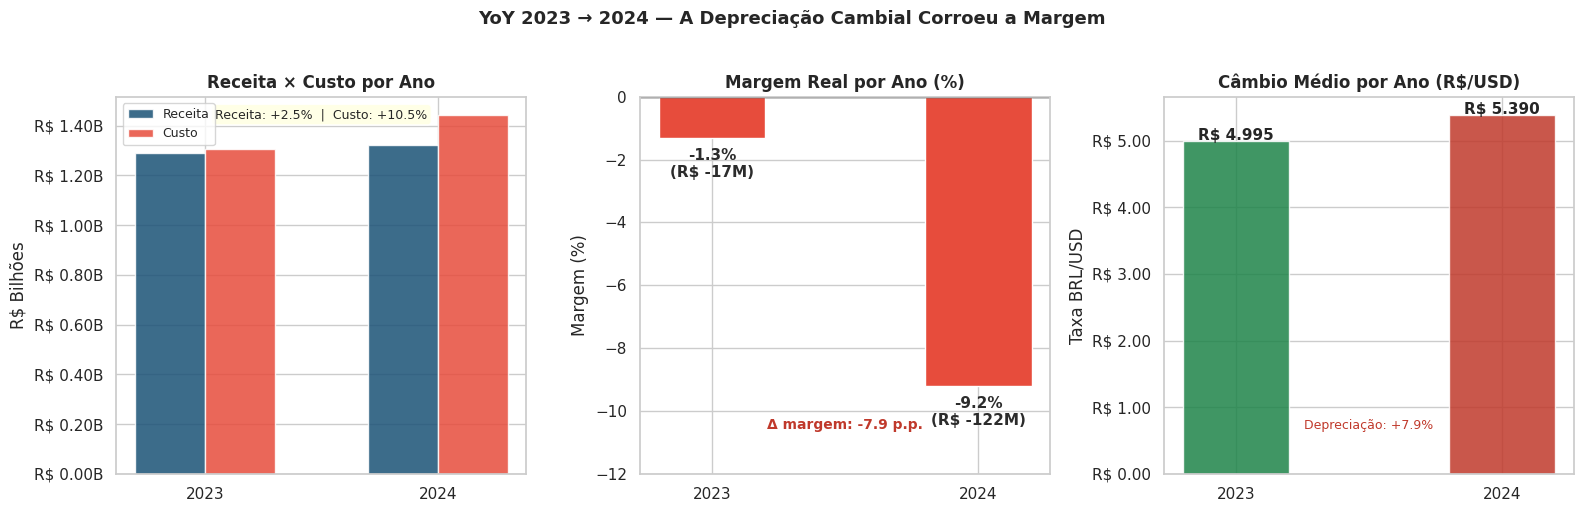

=== YoY: 2023 vs 2024 ===

2023:  Receita R$ 1.289B  |  Custo R$ 1.306B  |  Resultado R$ -17M  |  Margem -1.3%  |  Câmbio médio R$ 4.995

2024:  Receita R$ 1.321B  |  Custo R$ 1.443B  |  Resultado R$ -122M  |  Margem -9.2%  |  Câmbio médio R$ 5.390

Variação YoY:  receita +2.5%  |  custo +10.5%  |  margem -7.9 p.p.  |  câmbio +7.9%


In [0]:
# YoY: 2023 vs 2024 — a depreciação cambial corroeu a margem?
yoy = (
    vendas_enriquecido
    .groupby('ano')
    .agg(receita=('total', 'sum'), custo=('custo_brl', 'sum'),
         lucro=('lucro', 'sum'), transacoes=('id', 'count'))
    .assign(margem_pct=lambda d: d['lucro'] / d['receita'] * 100)
    .reset_index()
)

cambio_yoy = (
    cambio
    .assign(ano=lambda d: d['data'].dt.year)
    .groupby('ano')['taxa_brl'].mean()
    .reset_index().rename(columns={'taxa_brl': 'cambio_medio'})
)
yoy = yoy.merge(cambio_yoy, on='ano').reset_index(drop=True)

var_receita = (yoy.loc[1, 'receita']      / yoy.loc[0, 'receita']      - 1) * 100
var_custo   = (yoy.loc[1, 'custo']        / yoy.loc[0, 'custo']        - 1) * 100
var_margem  =  yoy.loc[1, 'margem_pct']   - yoy.loc[0, 'margem_pct']
var_cambio  = (yoy.loc[1, 'cambio_medio'] / yoy.loc[0, 'cambio_medio'] - 1) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Receita × Custo ---
ax0 = axes[0]
x, w = np.arange(2), 0.3
ax0.bar(x - w/2, yoy['receita'] / 1e9, w, label='Receita', color='#1a5276', alpha=0.85)
ax0.bar(x + w/2, yoy['custo']   / 1e9, w, label='Custo',   color='#e74c3c', alpha=0.85)
ax0.set_xticks(x)
ax0.set_xticklabels(yoy['ano'].astype(str))
ax0.set_title('Receita × Custo por Ano', fontweight='bold')
ax0.set_ylabel('R$ Bilhões')
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:.2f}B'))
ax0.legend(fontsize=9)
ax0.text(0.5, 0.97,
         f'Receita: {var_receita:+.1f}%  |  Custo: {var_custo:+.1f}%',
         transform=ax0.transAxes, ha='center', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Margem por ano ---
ax1 = axes[1]
cores_m = ['#e74c3c' if m < 0 else '#1e8449' for m in yoy['margem_pct']]
bars = ax1.bar(yoy['ano'].astype(str), yoy['margem_pct'], color=cores_m, width=0.4)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('Margem Real por Ano (%)', fontweight='bold')
ax1.set_ylabel('Margem (%)')
ax1.set_ylim(-12, 0)
for bar, row in zip(bars, yoy.itertuples()):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.3,
             f'{row.margem_pct:.1f}%\n(R$ {row.lucro/1e6:.0f}M)',
             ha='center', va='top', fontweight='bold', fontsize=11, color='#2c2c2c')
ax1.text(0.5, 0.12, f'Δ margem: {var_margem:+.1f} p.p.',
         transform=ax1.transAxes, ha='center', fontsize=10,
         color='#c0392b', fontweight='bold')

# --- Câmbio médio por ano ---
ax2 = axes[2]
bars2 = ax2.bar(yoy['ano'].astype(str), yoy['cambio_medio'],
                color=['#1e8449', '#c0392b'], width=0.4, alpha=0.85)
ax2.set_title('Câmbio Médio por Ano (R$/USD)', fontweight='bold')
ax2.set_ylabel('Taxa BRL/USD')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.2f'))
for bar, row in zip(bars2, yoy.itertuples()):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'R$ {row.cambio_medio:.3f}', ha='center', fontsize=11, fontweight='bold')
ax2.text(0.5, 0.12, f'Depreciação: {var_cambio:+.1f}%',
         transform=ax2.transAxes, ha='center', fontsize=9, color='#c0392b')

plt.suptitle('YoY 2023 → 2024 — A Depreciação Cambial Corroeu a Margem',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../assets/img/cambio_culpado.png", dpi=150, bbox_inches="tight")
plt.show()

print('=== YoY: 2023 vs 2024 ===')
for _, row in yoy.iterrows():
    print(f'\n{int(row.ano)}:  Receita R$ {row.receita/1e9:.3f}B  |  '
          f'Custo R$ {row.custo/1e9:.3f}B  |  Resultado R$ {row.lucro/1e6:.0f}M  |  '
          f'Margem {row.margem_pct:.1f}%  |  Câmbio médio R$ {row.cambio_medio:.3f}')
print(f'\nVariação YoY:  receita {var_receita:+.1f}%  |  custo {var_custo:+.1f}%  |  '
      f'margem {var_margem:+.1f} p.p.  |  câmbio {var_cambio:+.1f}%')

## 10. Simulador de Cenario Cambial

E se o dolar melhorar? Para cada taxa testada, recalculamos o custo de todas as 9.895 transacoes com a nova taxa fixa e verificamos quantos produtos ficam positivos.

Quatro cenarios: **Atual** (R$6,19) → **Otimista** (R$5,50) → **Base** (R$5,00) → **Meta** (R$4,72 — minimo historico do periodo).

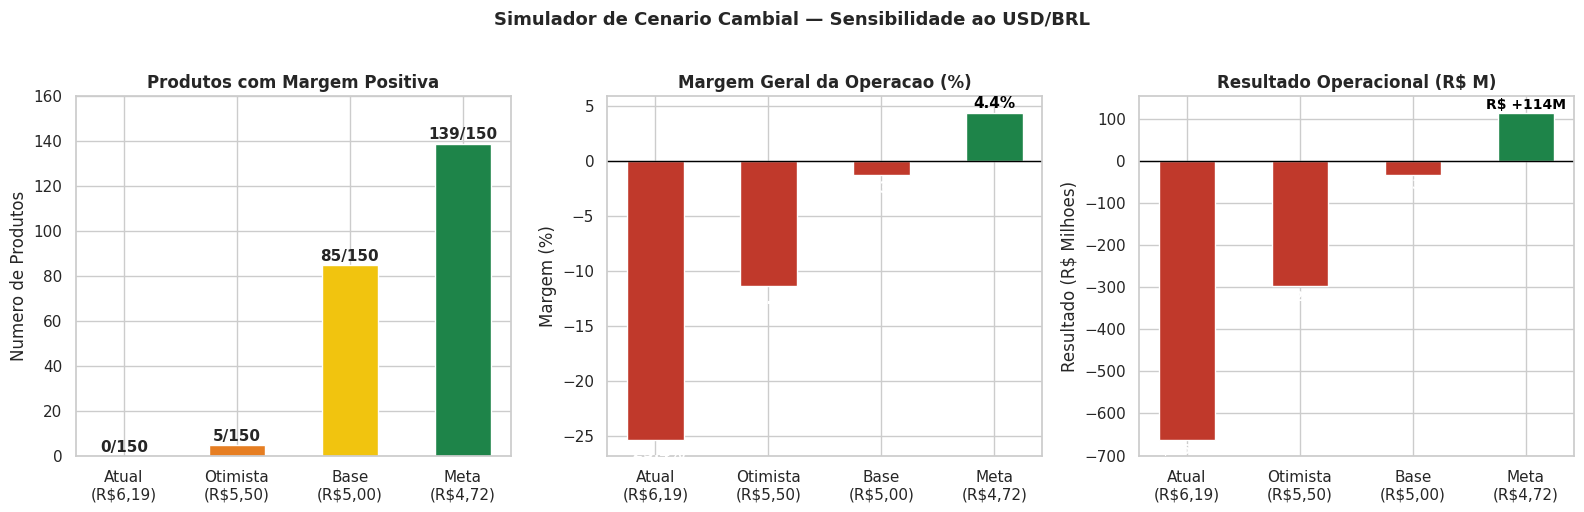

=== SIMULADOR DE CENARIO CAMBIAL ===
Cenario                   Taxa   Prod+    Margem     Resultado
--------------------------------------------------------------
Atual (R$6,19)         R$ 6.19      0/150    -25.4%  R$     -663M
Otimista (R$5,50)      R$ 5.50      5/150    -11.4%  R$     -298M
Base (R$5,00)          R$ 5.00     85/150     -1.3%  R$      -34M
Meta (R$4,72)          R$ 4.72    139/150      4.4%  R$     +114M

Para a operacao virar lucrativa com os precos atuais,
o USD/BRL precisaria cair abaixo do break-even medio de cada produto.


In [0]:
# Simulador de Cenario Cambial — "e se o dolar melhorar?"
cenarios = {
    'Atual\n(R$6,19)':    6.19,
    'Otimista\n(R$5,50)': 5.50,
    'Base\n(R$5,00)':     5.00,
    'Meta\n(R$4,72)':     4.72,
}

receita_total = vendas_enriquecido['total'].sum()
rows = []

for nome, taxa in cenarios.items():
    custo_novo = vendas_enriquecido['qtd'] * vendas_enriquecido['usd_price_vigente'] * taxa
    lucro_novo = vendas_enriquecido['total'] - custo_novo

    por_produto = (
        vendas_enriquecido
        .assign(lucro_n=lucro_novo)
        .groupby('id_product')
        .agg(receita=('total', 'sum'), lucro=('lucro_n', 'sum'))
    )

    rows.append({
        'Cenario'            : nome,
        'Taxa'               : taxa,
        'Produtos Positivos' : int((por_produto['lucro'] >= 0).sum()),
        'Margem Geral'       : round(lucro_novo.sum() / receita_total * 100, 1),
        'Resultado M'        : round(lucro_novo.sum() / 1e6, 0),
    })

df_sim = pd.DataFrame(rows)

# --- Graficos ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
nomes  = [r['Cenario'] for r in rows]
taxas  = [r['Taxa']    for r in rows]

# Palete: vermelho no atual, evoluindo para verde
cores_sim = ['#c0392b', '#e67e22', '#f1c40f', '#1e8449']

# Painel 1: Produtos positivos
ax0 = axes[0]
bars = ax0.bar(nomes, df_sim['Produtos Positivos'], color=cores_sim, width=0.5)
ax0.set_title('Produtos com Margem Positiva', fontweight='bold')
ax0.set_ylabel('Numero de Produtos')
ax0.set_ylim(0, 160)
for bar, val in zip(bars, df_sim['Produtos Positivos']):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val}/150', ha='center', fontsize=11, fontweight='bold')

# Painel 2: Margem geral
ax1 = axes[1]
cores_m = ['#c0392b' if m < 0 else '#1e8449' for m in df_sim['Margem Geral']]
bars2 = ax1.bar(nomes, df_sim['Margem Geral'], color=cores_m, width=0.5)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('Margem Geral da Operacao (%)', fontweight='bold')
ax1.set_ylabel('Margem (%)')
for bar, val in zip(bars2, df_sim['Margem Geral']):
    ypos = bar.get_height() + 0.2 if val >= 0 else bar.get_height() - 0.5
    ax1.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val}%', ha='center', fontsize=11, fontweight='bold',
             color='white' if val < -1 else 'black', va='top' if val < 0 else 'bottom')

# Painel 3: Resultado total
ax2 = axes[2]
cores_r = ['#c0392b' if r < 0 else '#1e8449' for r in df_sim['Resultado M']]
bars3 = ax2.bar(nomes, df_sim['Resultado M'], color=cores_r, width=0.5)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Resultado Operacional (R$ M)', fontweight='bold')
ax2.set_ylabel('Resultado (R$ Milhoes)')
for bar, val in zip(bars3, df_sim['Resultado M']):
    ypos = bar.get_height() + 2 if val >= 0 else bar.get_height() - 8
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'R$ {int(val):+}M', ha='center', fontsize=10, fontweight='bold',
             color='white' if val < -20 else 'black', va='top' if val < 0 else 'bottom')

plt.suptitle('Simulador de Cenario Cambial — Sensibilidade ao USD/BRL',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== SIMULADOR DE CENARIO CAMBIAL ===')
print(f'{"Cenario":<22} {"Taxa":>7}  {"Prod+":>6}  {"Margem":>8}  {"Resultado":>12}')
print('-' * 62)
for r in rows:
    nome_limpo = r['Cenario'].replace('\n', ' ')
    print(f'{nome_limpo:<22} R${r["Taxa"]:>5.2f}  {r["Produtos Positivos"]:>5}/150'
          f'  {r["Margem Geral"]:>7.1f}%  R$ {int(r["Resultado M"]):>+8}M')
print(f'\nPara a operacao virar lucrativa com os precos atuais,')
print(f'o USD/BRL precisaria cair abaixo do break-even medio de cada produto.')

## 11. Reajuste de Preco Necessario por Produto

Quanto cada produto precisa subir para atingir margem zero com o cambio atual (R$6,19)?

**Calculo:** `reajuste% = (custo_USD_medio × R$6,19 / preco_BRL_medio) - 1`

Produtos ja positivos ficam com reajuste = 0%. O resultado e uma lista de acao direta para a equipe comercial.

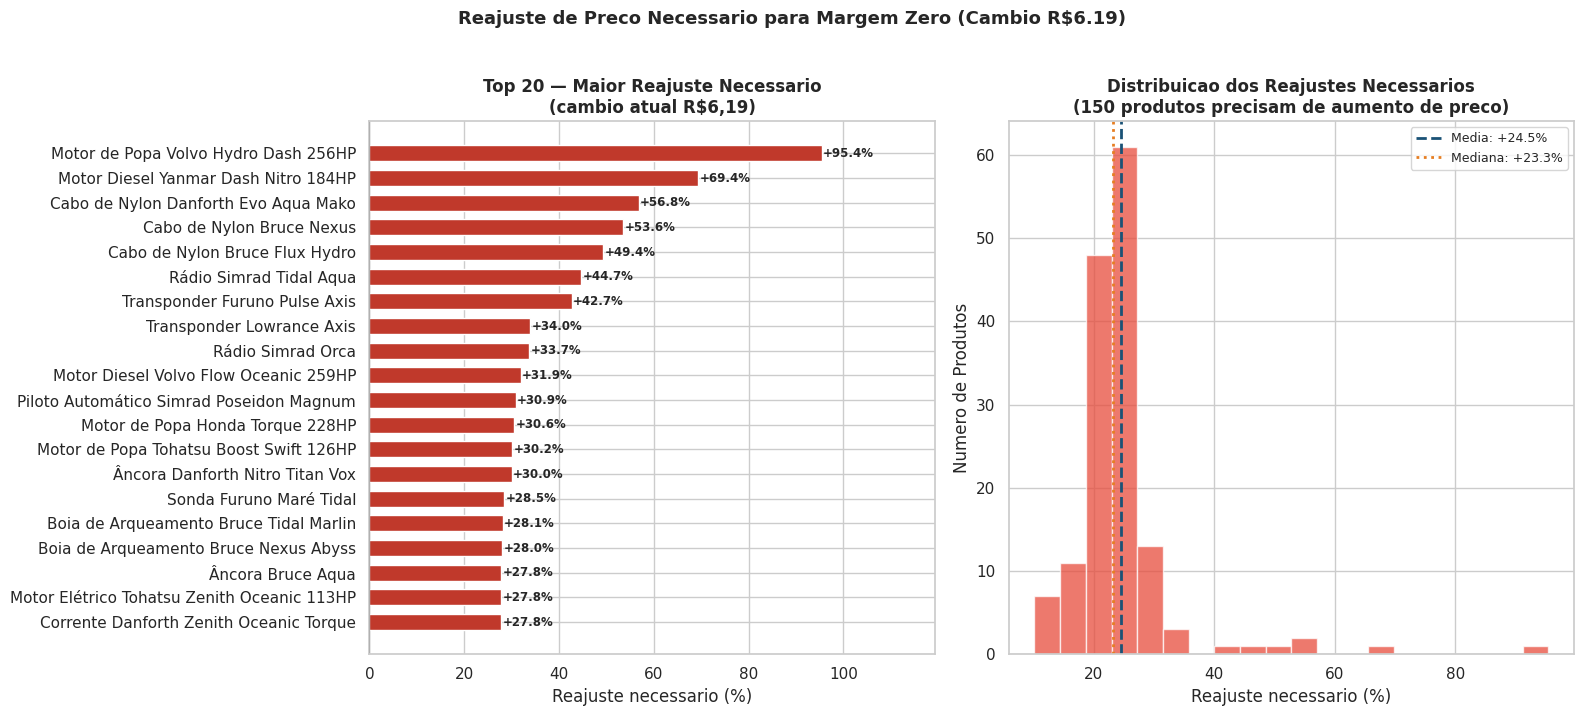

Taxa de cambio referencia : R$ 6.1900 (dez/2024)
Produtos que ja sao positivos: 0/150 (sem necessidade de reajuste)
Produtos que precisam reajuste: 150/150
Reajuste medio necessario : +24.5%
Reajuste mediano necessario: +23.3%
Maior reajuste necessario : +95.4% (Motor de Popa Volvo Hydro Dash 256HP)

=== TOP 10 PRODUTOS — MAIOR REAJUSTE NECESSARIO ===
                              Produto   Categoria  Preco Medio (R$)  Custo R$6,19  Margem Atual (%)  Reajuste Necessario (%)
 Motor de Popa Volvo Hydro Dash 256HP   propulsão      97173.032847 189881.221200             -63.2                     95.4
 Motor Diesel Yanmar Dash Nitro 184HP   propulsão     130974.250542 221847.743000             -41.9                     69.4
 Cabo de Nylon Danforth Evo Aqua Mako   ancoragem        608.303548    954.057309             -31.1                     56.8
            Cabo de Nylon Bruce Nexus   ancoragem        805.807407   1237.566700             -28.8                     53.6
       Cabo de Nylon 

In [0]:
# Reajuste de Preco Necessario por Produto — com cambio atual (R$6,19)
taxa_atual = 6.19  # R$6,19 — referência do relatório

# preco_unit_brl foi calculado no cell-15 e já está em vendas_enriquecido
reajuste = (
    vendas_enriquecido
    .merge(produtos_df, left_on='id_product', right_on='id_product')
    .groupby(['id_product', 'name', 'actual_category'])
    .agg(
        preco_medio_brl  =('preco_unit_brl',   'mean'),
        custo_medio_usd  =('usd_price_vigente', 'mean'),
        receita_total    =('total',             'sum'),
        lucro_atual      =('lucro',             'sum'),
    )
    .reset_index()
    .assign(
        custo_brl_taxa_atual  =lambda d: d['custo_medio_usd'] * taxa_atual,
        reajuste_pct          =lambda d: ((d['custo_brl_taxa_atual'] / d['preco_medio_brl']) - 1).clip(lower=0).mul(100).round(1),
        margem_atual_pct      =lambda d: (d['lucro_atual'] / d['receita_total'] * 100).round(1),
    )
    .sort_values('reajuste_pct', ascending=False)
    .reset_index(drop=True)
)

ja_positivos = (reajuste['reajuste_pct'] == 0).sum()
precisa_reajuste = (reajuste['reajuste_pct'] > 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 20 com maior reajuste necessario
top20 = reajuste.head(20)
cores = ['#c0392b' if r > 20 else '#e67e22' if r > 10 else '#f1c40f'
         for r in top20['reajuste_pct']]
bars = axes[0].barh(top20['name'], top20['reajuste_pct'], color=cores, height=0.65)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 20 — Maior Reajuste Necessario\n(cambio atual R$6,19)', fontweight='bold')
axes[0].set_xlabel('Reajuste necessario (%)')
axes[0].invert_yaxis()
for bar, row in zip(bars, top20.itertuples()):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'+{row.reajuste_pct:.1f}%', va='center', fontsize=8.5, fontweight='bold')
axes[0].set_xlim(0, top20['reajuste_pct'].max() * 1.25)

# Distribuicao dos reajustes (histograma)
reajuste_pos = reajuste[reajuste['reajuste_pct'] > 0]
axes[1].hist(reajuste_pos['reajuste_pct'], bins=20, color='#e74c3c', alpha=0.75, edgecolor='white')
axes[1].axvline(reajuste_pos['reajuste_pct'].mean(), color='#1a5276', linewidth=2,
                linestyle='--', label=f'Media: +{reajuste_pos["reajuste_pct"].mean():.1f}%')
axes[1].axvline(reajuste_pos['reajuste_pct'].median(), color='#e67e22', linewidth=2,
                linestyle=':', label=f'Mediana: +{reajuste_pos["reajuste_pct"].median():.1f}%')
axes[1].set_title(f'Distribuicao dos Reajustes Necessarios\n({precisa_reajuste} produtos precisam de aumento de preco)',
                  fontweight='bold')
axes[1].set_xlabel('Reajuste necessario (%)')
axes[1].set_ylabel('Numero de Produtos')
axes[1].legend(fontsize=9)

plt.suptitle(f'Reajuste de Preco Necessario para Margem Zero (Cambio R${taxa_atual:.2f})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../assets/img/reajuste_necessario.png", dpi=150, bbox_inches="tight")
plt.show()

print(f'Taxa de cambio referencia : R$ {taxa_atual:.4f} (dez/2024)')
print(f'Produtos que ja sao positivos: {ja_positivos}/150 (sem necessidade de reajuste)')
print(f'Produtos que precisam reajuste: {precisa_reajuste}/150')
print(f'Reajuste medio necessario : +{reajuste_pos["reajuste_pct"].mean():.1f}%')
print(f'Reajuste mediano necessario: +{reajuste_pos["reajuste_pct"].median():.1f}%')
print(f'Maior reajuste necessario : +{reajuste["reajuste_pct"].max():.1f}% ({reajuste.iloc[0]["name"]})')

print(f'\n=== TOP 10 PRODUTOS — MAIOR REAJUSTE NECESSARIO ===')
print(
    reajuste.head(10)[['name', 'actual_category', 'preco_medio_brl', 'custo_brl_taxa_atual', 'margem_atual_pct', 'reajuste_pct']]
    .rename(columns={
        'name'              : 'Produto',
        'actual_category'   : 'Categoria',
        'preco_medio_brl'   : 'Preco Medio (R$)',
        'custo_brl_taxa_atual': 'Custo R$6,19',
        'margem_atual_pct'  : 'Margem Atual (%)',
        'reajuste_pct'      : 'Reajuste Necessario (%)',
    })
    .to_string(index=False)
)

## 12. Resumo Executivo

### Para o Gabriel (Tech Lead)
Analise conduzida com Spark SQL SQL em CTE dupla: `custo_vigente` (subquery correlacionada para vigencia temporal de custo) + JOIN com cambio diario BCB. A serie PTAX (502 dias uteis) e baixada em uma chamada HTTP, persistida como silver_cambio (Delta Lake) e disponivel para as etapas 4, 6 e 7.

### Para a Marina (Gerente de Negocios)

| Metrica | Valor |
|---|---|
| Receita total 2023-2024 | R$ 2,61 bilhoes |
| Custo total (cambio real) | R$ 2,75 bilhoes |
| **Resultado operacional** | **R$ -139M (margem: -5,3%)** |
| YoY: margem 2023 vs 2024 | -1,3% → -9,2% (deterioracao de -7,9 p.p.) |
| Produtos com prejuizo | 127 de 150 (84,7%) |
| 25 produtos = 80% do prejuizo | foco prioritario para reajuste |
| Pior produto | Motor Volvo Hydro Dash 256HP — R$ -39,8M (-63,2%) |
| Simulador: meta R$4,72 | operacao lucrativa com precos atuais |

**Acoes recomendadas:**
1. **Reajuste de precos** dos 25 produtos criticos (80% do prejuizo)
2. **Politica de repasse cambial** — atualizar lista quando USD/BRL superar R$5,50
3. **Hedge cambial** para contratos de importacao acima de USD 1M
4. **Descontinuacao** dos produtos com prejuizo > R$5M e baixo volume

### Para o Sr. Almir (Fundador)
A empresa faturou R$ 2,6 bilhoes — mas quando calculamos o custo real das importacoes
com o cambio do dia, gastamos R$ 139 milhoes a mais do que recebemos.
O problema piorou: em 2023 o prejuizo foi de apenas R$ 17M (-1,3%). Em 2024 saltou para R$ 122M (-9,2%).
O dolar saiu de R$ 4,72 em 2023 e chegou a R$ 6,20 no fim de 2024 — e os precos nao acompanharam.
O simulador mostra que se o dolar voltar ao minimo historico do periodo (R$ 4,72), a operacao ficaria lucrativa com os precos atuais. Ate la, o reajuste de precos e urgente.

In [0]:
def run_all_quality_checks_vendas(vendas_df, produtos_df_local, cambio_df):
    """Checks críticos de consistência para a Etapa 3."""
    checks = {
        'vendas_gold_colunas_criticas': set(['id', 'id_product', 'total', 'custo_brl', 'lucro', 'sale_date']).issubset(vendas_df.columns),
        'cambio_colunas_criticas': set(['data', 'taxa_brl']).issubset(cambio_df.columns),
        'reconciliacao_financeira': np.isclose((vendas_df['total'].sum() - vendas_df['custo_brl'].sum() - vendas_df['lucro'].sum()), 0, atol=1e-2),
        'cambio_sem_nulos': cambio_df['taxa_brl'].isna().sum() == 0,
        'margem_global_negativa': (vendas_df['lucro'].sum() / vendas_df['total'].sum() * 100) < 0,
        'produtos_validos_no_join': vendas_df['id_product'].isin(produtos_df_local['id_product']).all(),
    }
    qa = pd.DataFrame({'check': checks.keys(), 'status': checks.values()})
    qa['resultado'] = qa['status'].map({True: 'PASS', False: 'FAIL'})
    return qa

qa_vendas = run_all_quality_checks_vendas(vendas_enriquecido, produtos_df, cambio)
print(qa_vendas[['check', 'resultado']].to_string(index=False))

if qa_vendas['status'].all():
    print('RUN_ALL CHECKS (ETAPA 3): PASS')
else:
    print('RUN_ALL CHECKS (ETAPA 3): FAIL')

                       check resultado
vendas_gold_colunas_criticas      PASS
     cambio_colunas_criticas      PASS
    reconciliacao_financeira      PASS
            cambio_sem_nulos      PASS
      margem_global_negativa      PASS
    produtos_validos_no_join      PASS
RUN_ALL CHECKS (ETAPA 3): PASS
